In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])
df.dropna(inplace=True)

print("Shape:", df.shape)
print("\nSample:")
print(df.head())
print("\nAge stats:")
print(df['Age'].describe().round(2))
print("\nFare stats:")
print(df['Fare'].describe().round(2))

Shape: (714, 3)

Sample:
   Survived   Age     Fare
0         0  22.0   7.2500
1         1  38.0  71.2833
2         1  26.0   7.9250
3         1  35.0  53.1000
4         0  35.0   8.0500

Age stats:
count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: Age, dtype: float64

Fare stats:
count    714.00
mean      34.69
std       52.92
min        0.00
25%        8.05
50%       15.74
75%       33.38
max      512.33
Name: Fare, dtype: float64


### Baseline - Without Binning

In [51]:
X = df.iloc[:, 1:]   # Age and Fare columns
y = df.iloc[:, 0]    # Survived column

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# baseline model without binning
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred)
cv_baseline  = np.mean(cross_val_score(
    DecisionTreeClassifier(), X, y,
    cv=10, scoring='accuracy'
))

print(f"Baseline accuracy (single split) : {baseline_acc:.4f}")
print(f"Baseline accuracy (10-fold CV)   : {cv_baseline:.4f}")

Baseline accuracy (single split) : 0.6224
Baseline accuracy (10-fold CV)   : 0.6317


### Apply KBinsDiscretizer

In [52]:
# n_bins=15   → divide each column into 15 groups
# encode='ordinal' → output as 0,1,2,3... (bin numbers)
# strategy='quantile' → each bin has equal number of samples

kbin_age  = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')

In [53]:
# ColumnTransformer applies different transformers
# to different columns in one step
#
# ('first', kbin_age, [0])  → apply kbin_age  to column index 0 (Age)
# ('second', kbin_fare, [1])→ apply kbin_fare to column index 1 (Fare)

trf = ColumnTransformer([
    ('first',  kbin_age,  [0]),
    ('second', kbin_fare, [1])
])

X_train_trf = trf.fit_transform(X_train)  # fit on train → transform train
X_test_trf  = trf.transform(X_test)       # only transform test (no fit!)

print("X_train_trf shape:", X_train_trf.shape)
print("\nFirst 5 rows after binning:")
print(X_train_trf[:5])

X_train_trf shape: (571, 2)

First 5 rows after binning:
[[8. 8.]
 [6. 7.]
 [8. 7.]
 [9. 2.]
 [6. 6.]]


c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


### Inspecting Binning Edges

In [54]:
# bin_edges_ shows where each bin starts and ends
age_edges  = trf.named_transformers_['first'].bin_edges_[0]
fare_edges = trf.named_transformers_['second'].bin_edges_[0]

print("Age bin edges:")
print(age_edges)
print(f"\nTotal age bins: {len(age_edges)-1}")

print("\nFare bin edges:")
print(fare_edges.round(2))
print(f"\nTotal fare bins: {len(fare_edges)-1}")

Age bin edges:
[ 0.42  6.   16.   19.   21.   23.   25.   28.   30.   32.   35.   38.
 42.   47.   54.   80.  ]

Total age bins: 15

Fare bin edges:
[  0.     7.25   7.78   7.9    8.16  10.5   13.    14.45  18.75  26.
  26.55  31.28  51.48  76.29 108.9  512.33]

Total fare bins: 15


### Visualize Binning

In [55]:
output = pd.DataFrame({
    'age'      : X_train['Age'].values,
    'age_bin'  : X_train_trf[:, 0],
    'fare'     : X_train['Fare'].values,
    'fare_bin' : X_train_trf[:, 1]
})

# add human readable labels using pd.cut
output['age_label']  = pd.cut(
    x=X_train['Age'],
    bins=age_edges.tolist()
)
output['fare_label'] = pd.cut(
    x=X_train['Fare'],
    bins=fare_edges.tolist()
)

print("Sample output — original vs binned:")
print(output.sample(8).to_string())

Sample output — original vs binned:
      age  age_bin      fare  fare_bin     age_label        fare_label
439  16.0      2.0    7.7750       2.0  (30.0, 32.0]     (8.158, 10.5]
122  31.0      8.0    7.7500       1.0  (32.0, 35.0]   (26.55, 31.275]
374  28.0      7.0   15.8500       7.0           NaN               NaN
268  28.0      7.0   82.1708      13.0  (54.0, 80.0]  (108.9, 512.329]
248  54.0     14.0   51.8625      12.0  (35.0, 38.0]  (51.479, 76.292]
498  45.5     12.0    7.2250       0.0           NaN               NaN
232  31.0      8.0  164.8667      14.0  (54.0, 80.0]    (13.0, 14.454]
372  14.0      1.0  120.0000      14.0  (16.0, 19.0]    (7.896, 8.158]


### Accuracy After Binning

In [56]:
clf_binned = DecisionTreeClassifier()
clf_binned.fit(X_train_trf, y_train)
y_pred2    = clf_binned.predict(X_test_trf)

binned_acc = accuracy_score(y_test, y_pred2)
X_trf_all  = trf.fit_transform(X)
cv_binned  = np.mean(cross_val_score(
    DecisionTreeClassifier(), X_trf_all, y,
    cv=10, scoring='accuracy'
))

print("=" * 45)
print(f"{'':20} {'Single':>10} {'CV':>10}")
print("=" * 45)
print(f"{'Without binning':<20} {baseline_acc:>10.4f} {cv_baseline:>10.4f}")
print(f"{'With binning':<20} {binned_acc:>10.4f} {cv_binned:>10.4f}")
print(f"{'Improvement':<20} {(binned_acc-baseline_acc)*100:>+9.2f}% {(cv_binned-cv_baseline)*100:>+9.2f}%")

                         Single         CV
Without binning          0.6224     0.6317
With binning             0.6364     0.6723
Improvement              +1.40%     +4.06%


c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategy     Bins      CV Accuracy


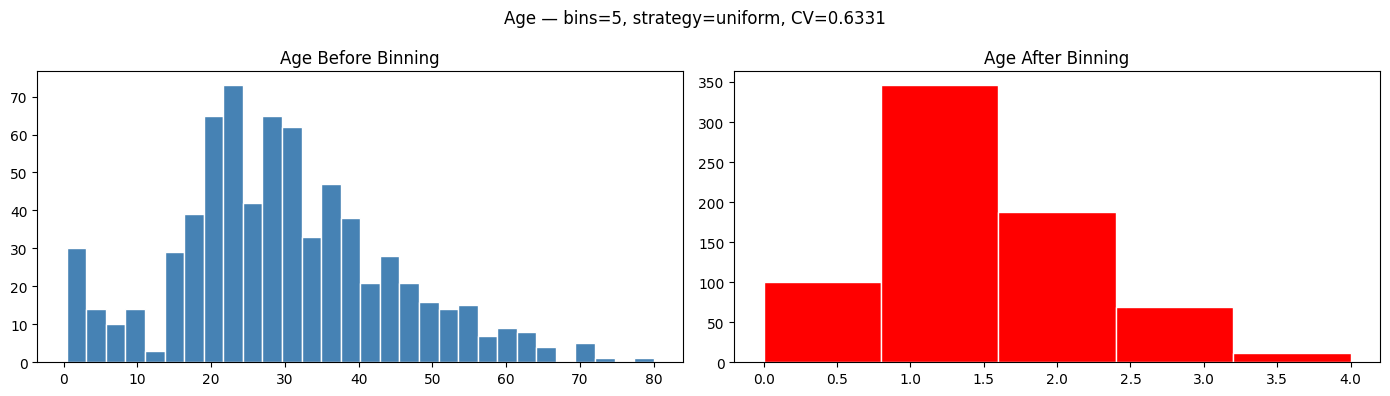

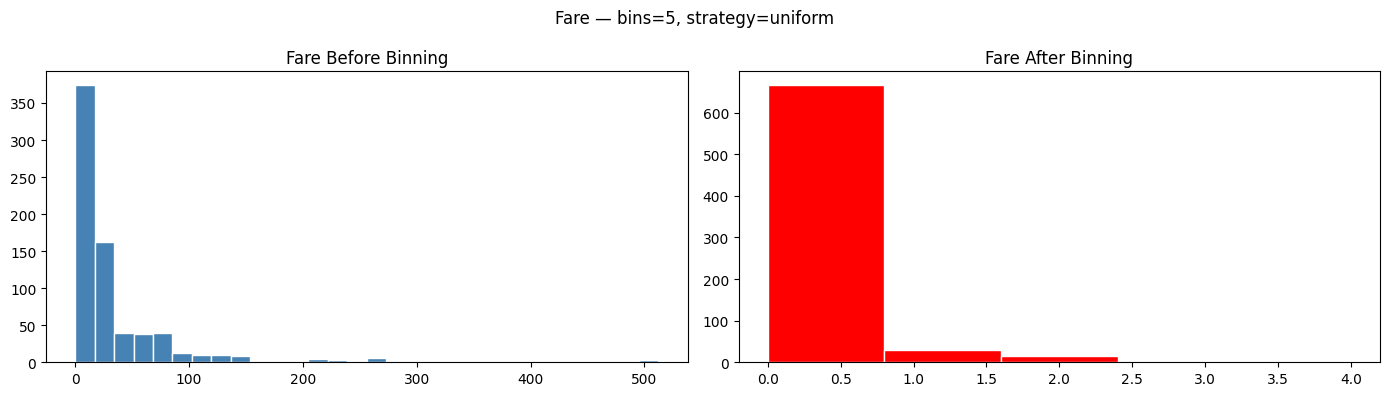

uniform      5              0.6331


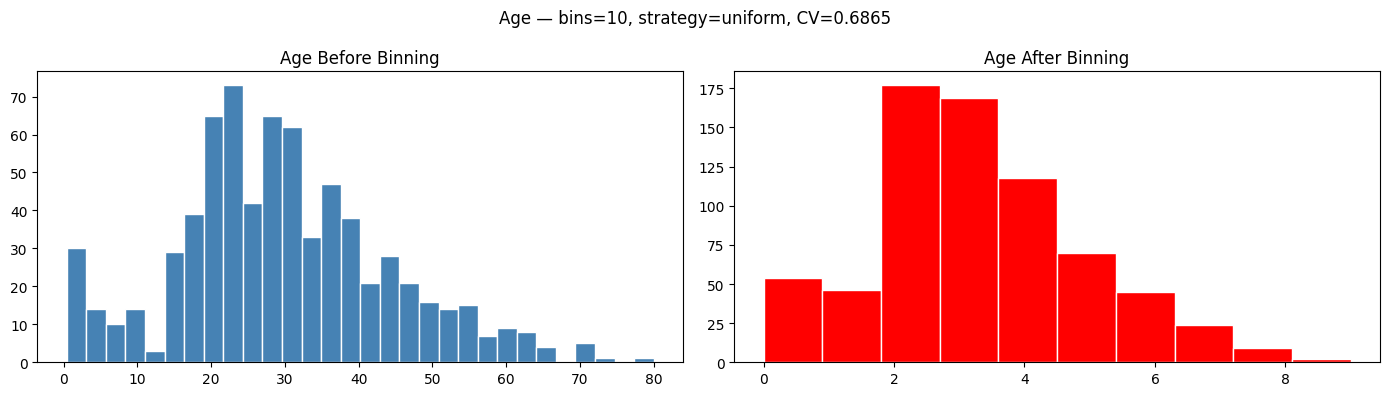

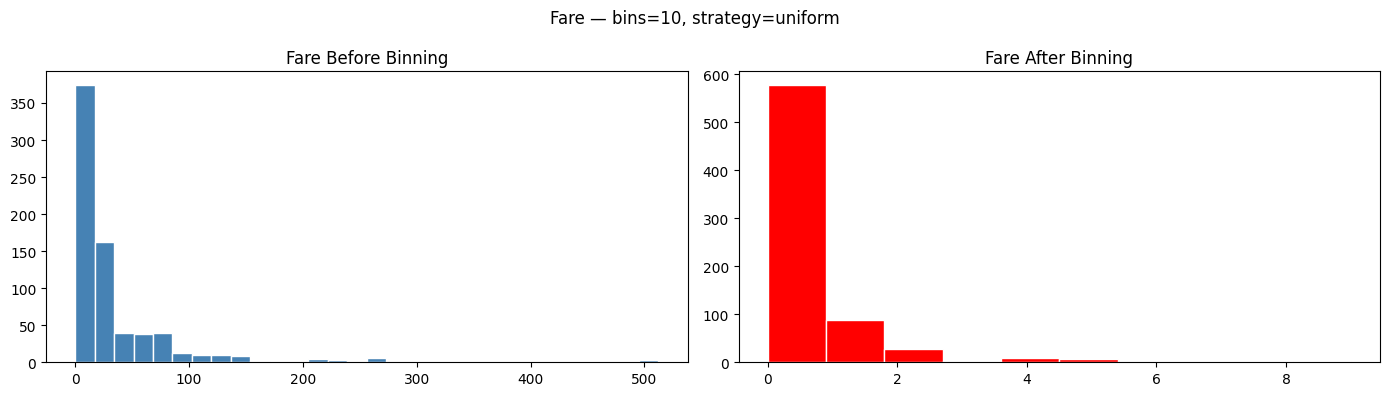

uniform      10             0.6865


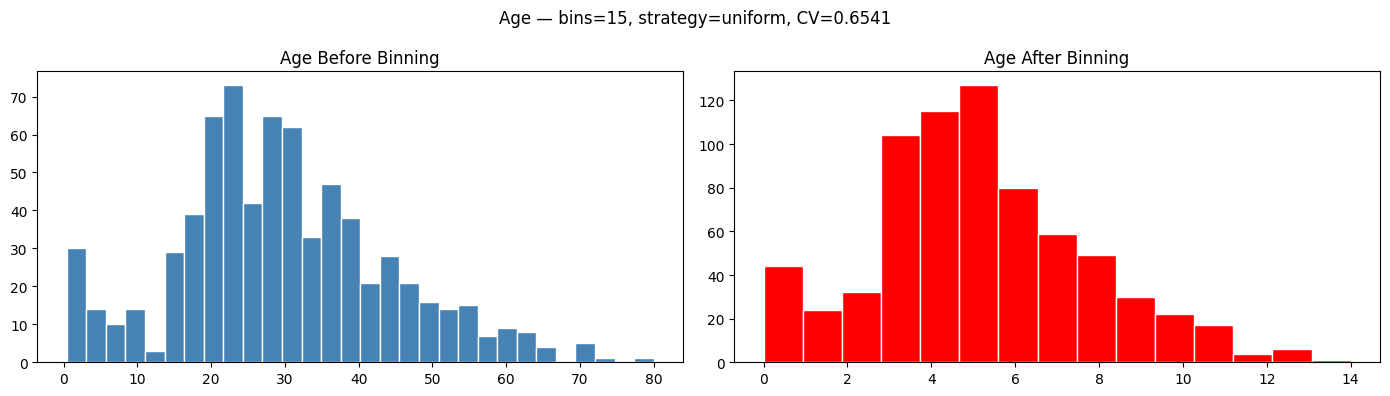

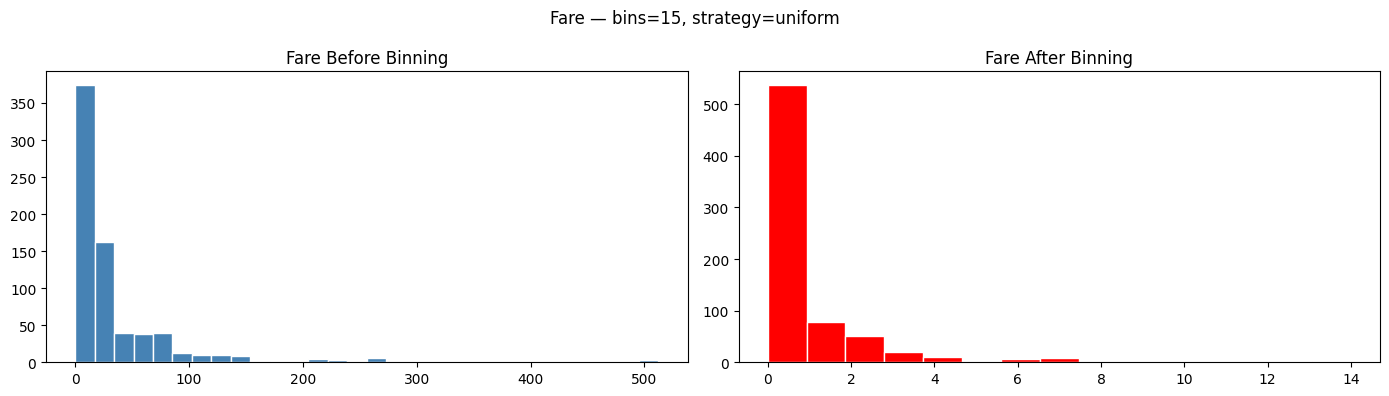

uniform      15             0.6541


c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


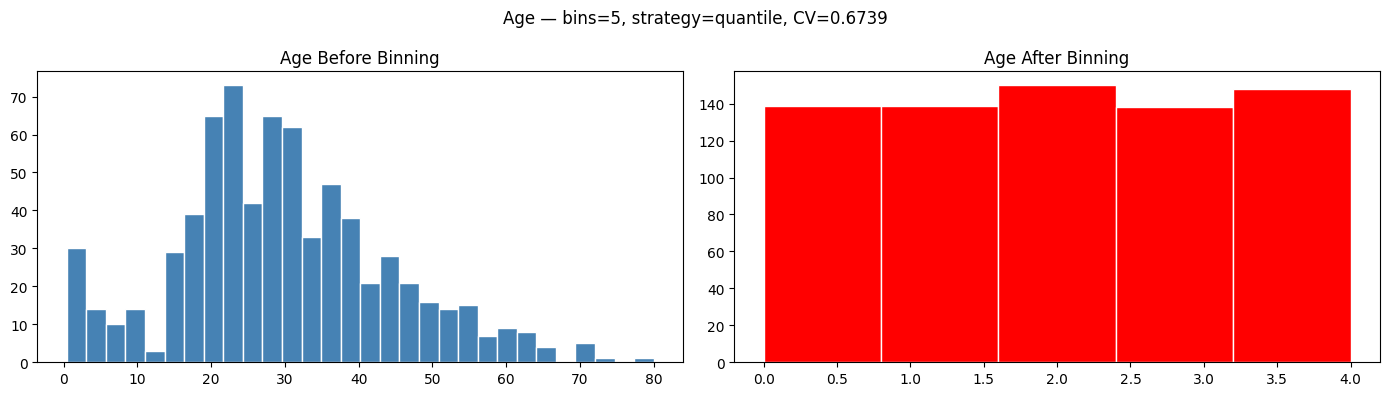

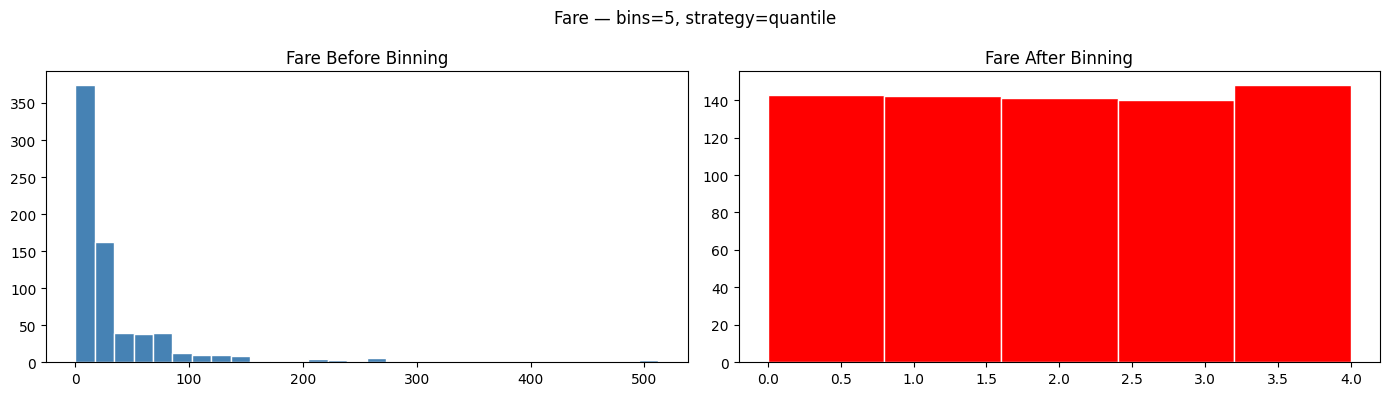

quantile     5              0.6739


c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


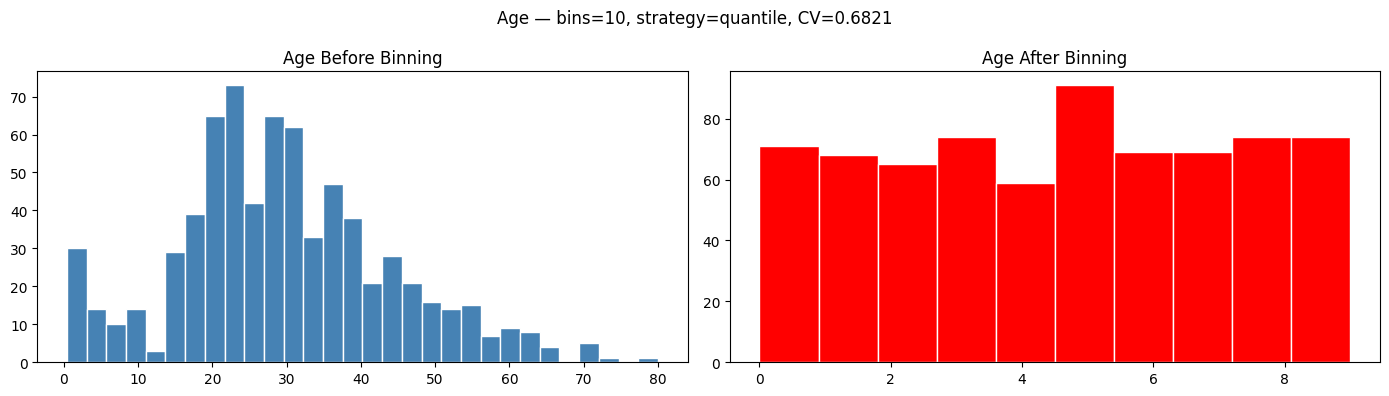

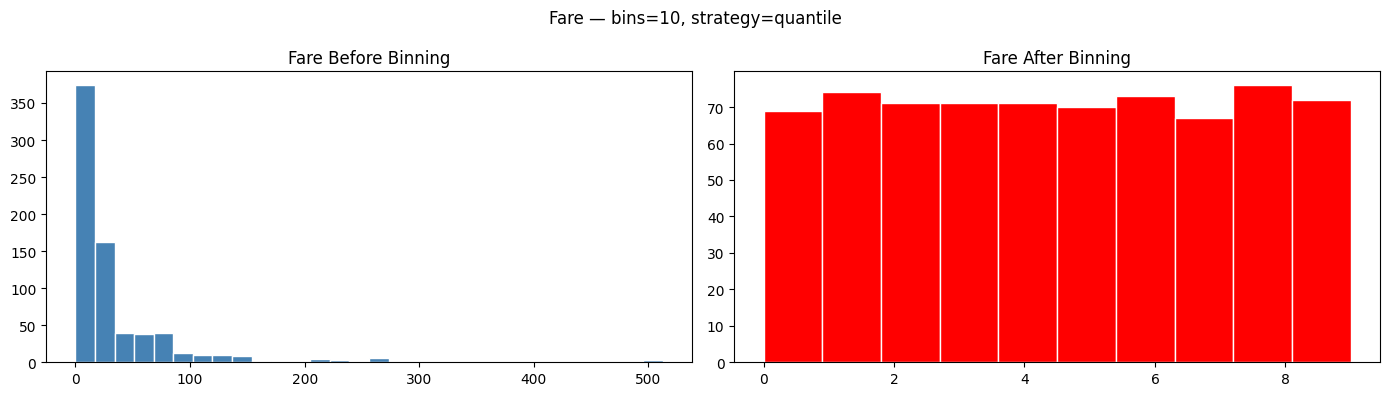

quantile     10             0.6821


c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\kinar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


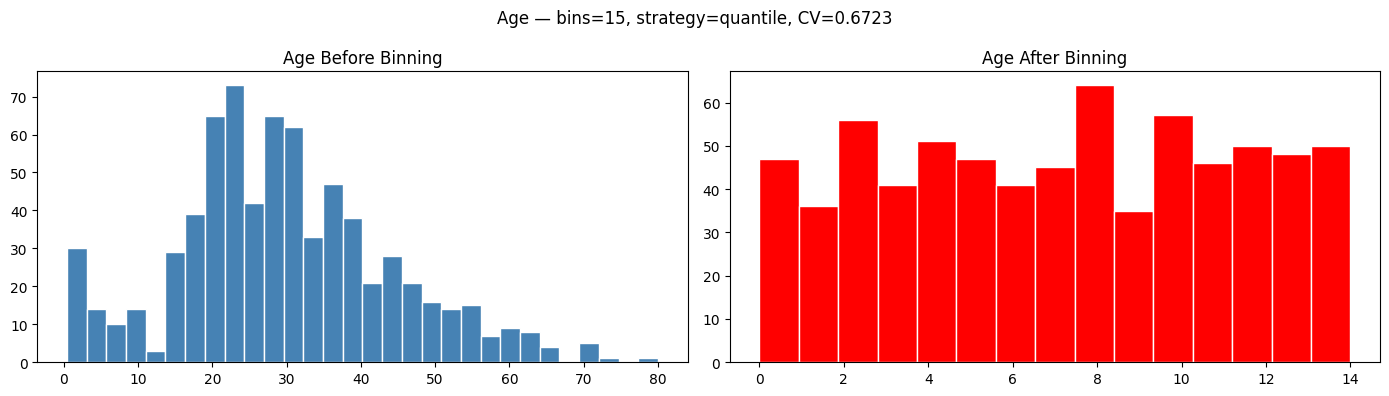

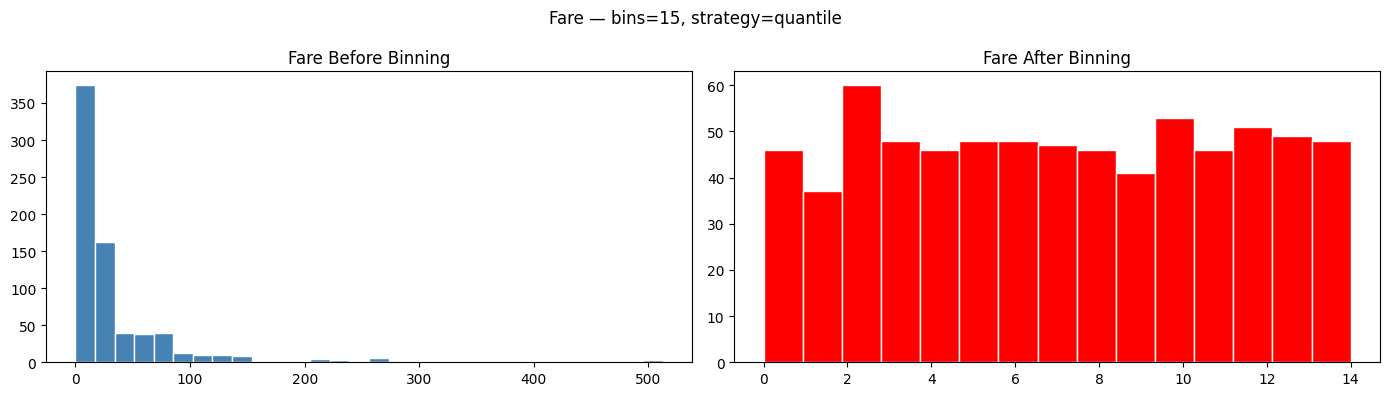

quantile     15             0.6723


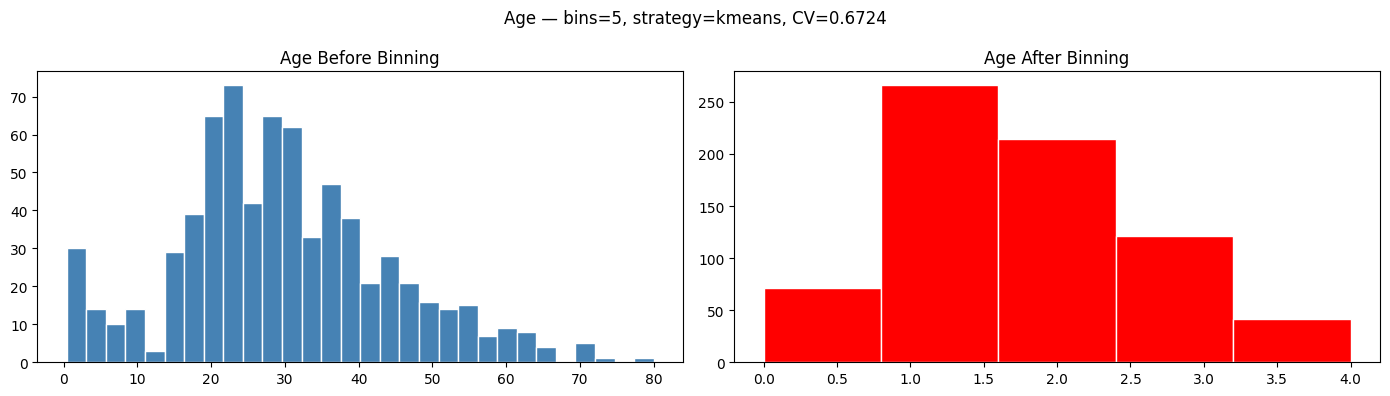

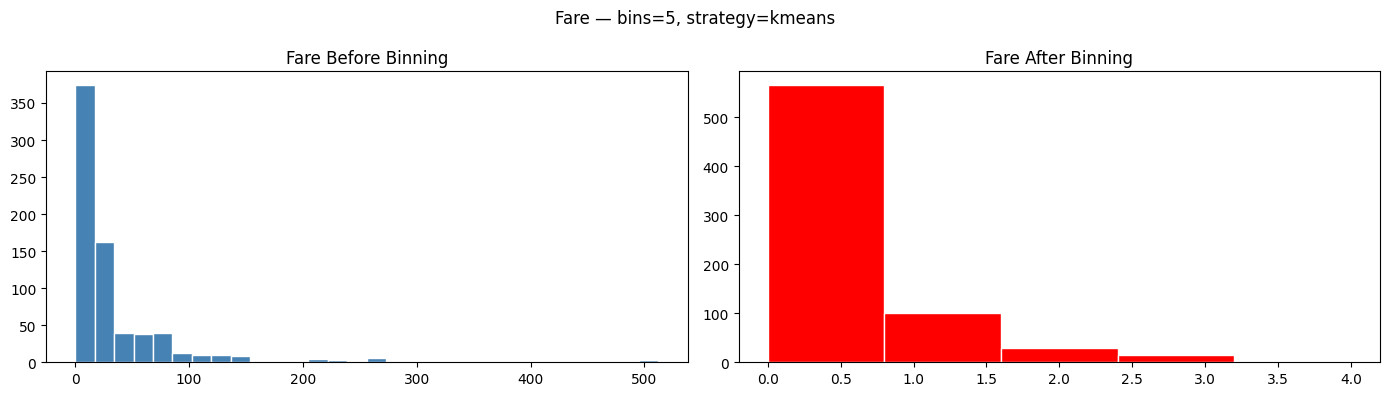

kmeans       5              0.6724


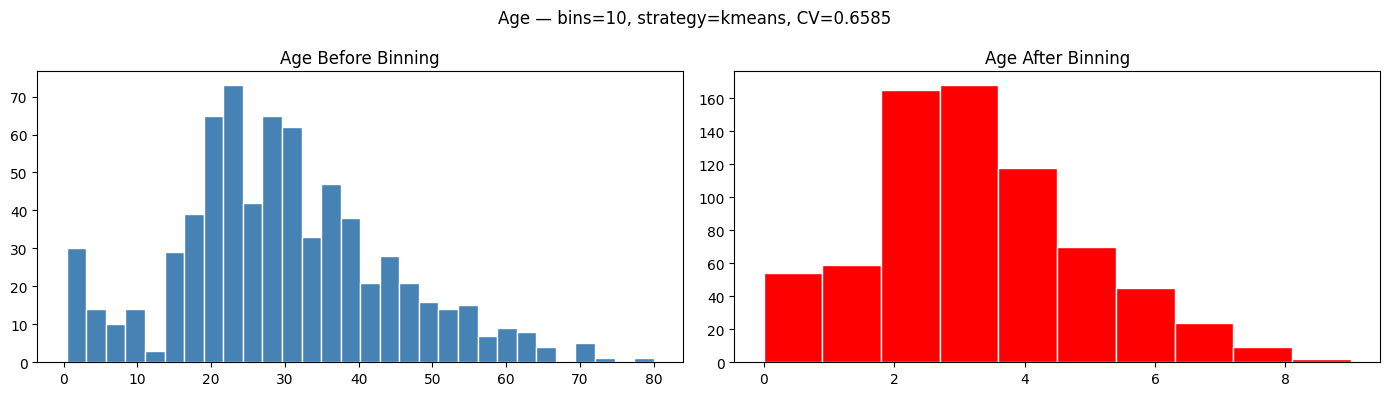

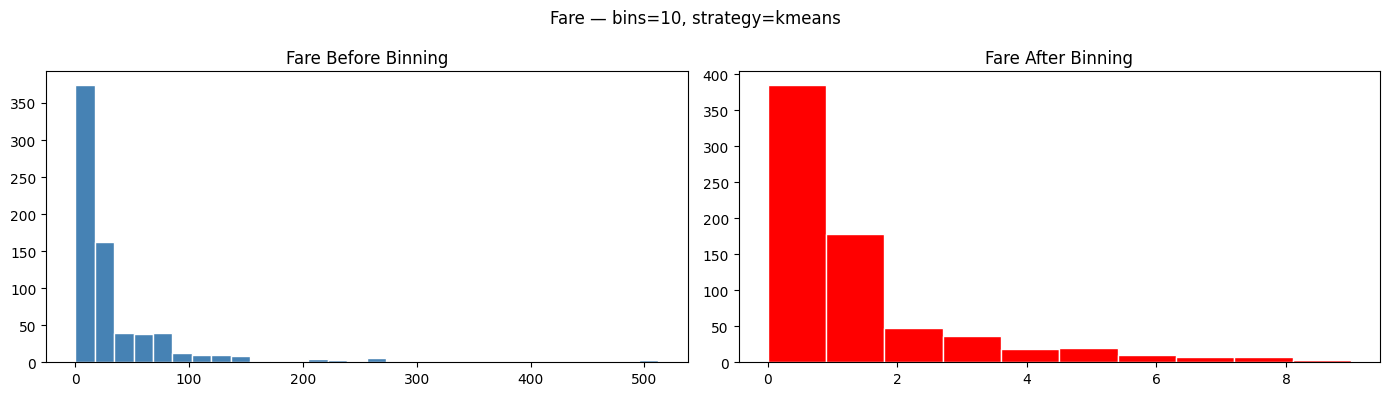

kmeans       10             0.6585


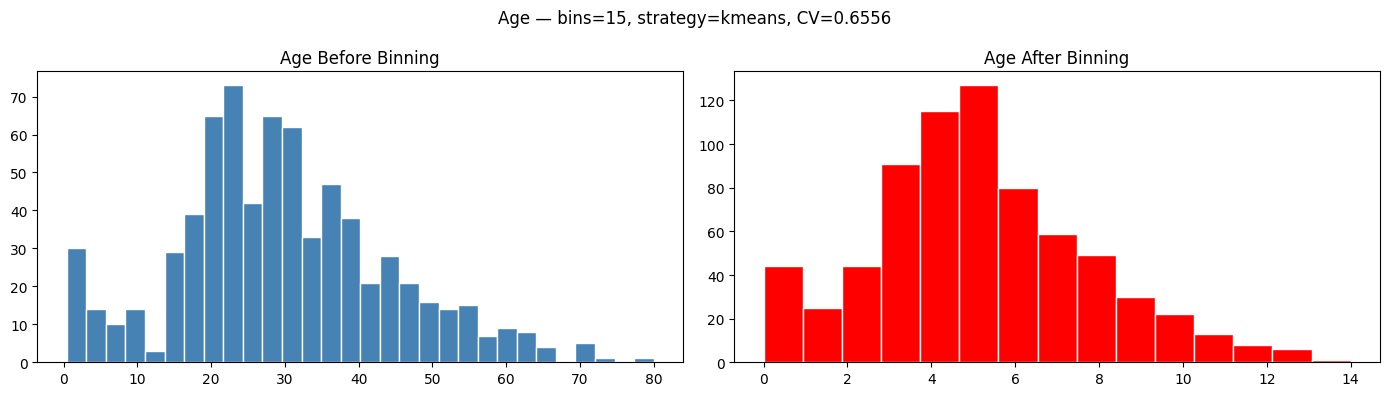

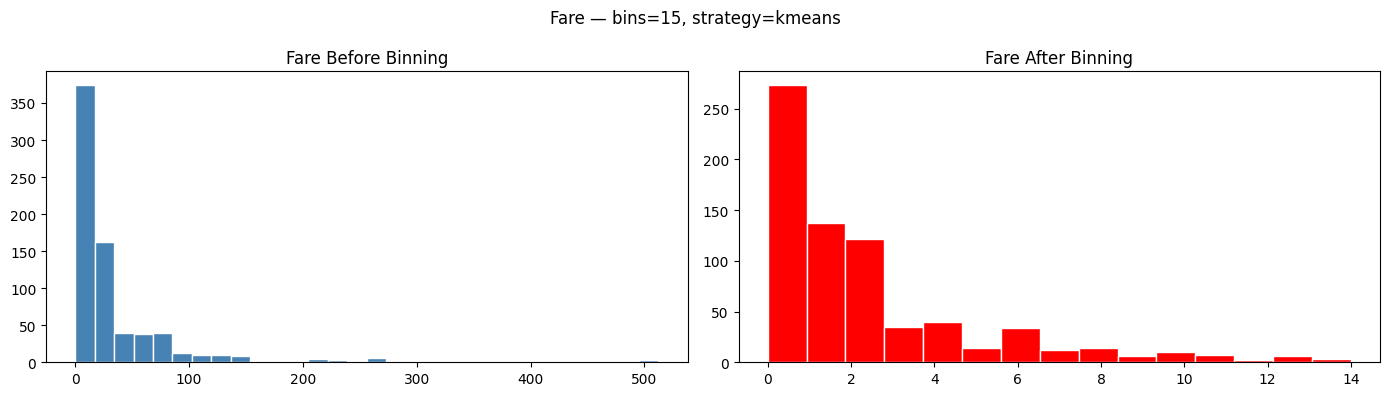

kmeans       15             0.6556

✅ Best combination:
   Strategy : uniform
   Bins     : 10
   CV Score : 0.6865


In [57]:
def discretize(bins, strategy):
    """
    bins     → how many groups to divide data into
    strategy → 'uniform', 'quantile', or 'kmeans'
    """

    # create binners
    kbin_age  = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    # column transformer
    trf = ColumnTransformer([
        ('first',  kbin_age,  [0]),
        ('second', kbin_fare, [1])
    ])

    # fit and transform full dataset for CV
    X_trf = trf.fit_transform(X)

    # cross validation score
    cv_score = np.mean(cross_val_score(
        DecisionTreeClassifier(),
        X_trf, y,
        cv=10,
        scoring='accuracy'
    ))

    # plot before and after for Age
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Age — bins={bins}, strategy={strategy}, CV={cv_score:.4f}")
    axes[0].hist(X['Age'],       bins=30, color='steelblue', edgecolor='white')
    axes[0].set_title("Age Before Binning")
    axes[1].hist(X_trf[:, 0],   bins=bins, color='red',       edgecolor='white')
    axes[1].set_title("Age After Binning")
    plt.tight_layout()
    plt.show()

    # plot before and after for Fare
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Fare — bins={bins}, strategy={strategy}")
    axes[0].hist(X['Fare'],      bins=30, color='steelblue', edgecolor='white')
    axes[0].set_title("Fare Before Binning")
    axes[1].hist(X_trf[:, 1],   bins=bins, color='red',       edgecolor='white')
    axes[1].set_title("Fare After Binning")
    plt.tight_layout()
    plt.show()

    return cv_score

# ── compare all strategies ─────────────────────────────────
print("=" * 50)
print(f"{'Strategy':<12} {'Bins':<8} {'CV Accuracy':>12}")
print("=" * 50)

results = []
for strategy in ['uniform', 'quantile', 'kmeans']:
    for bins in [5, 10, 15]:
        score = discretize(bins, strategy)
        results.append({
            'strategy': strategy,
            'bins'    : bins,
            'cv_score': score
        })
        print(f"{strategy:<12} {bins:<8} {score:>12.4f}")

results_df = pd.DataFrame(results)
best       = results_df.loc[results_df['cv_score'].idxmax()]
print(f"\n✅ Best combination:")
print(f"   Strategy : {best['strategy']}")
print(f"   Bins     : {int(best['bins'])}")
print(f"   CV Score : {best['cv_score']:.4f}")